In [81]:
import pandas as pd
import numpy as np
import scipy.io as sio
import torch
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from data_classes.decomposition import Extract_Features, PCA_features
import torchaudio

In [82]:
phase2_data = sio.loadmat('../data/phase2_data_20220215.mat')
samples  = pd.DataFrame(phase2_data["x"].T)
labels  = pd.DataFrame(phase2_data["y"].T, columns=["y"])

df = pd.concat([samples, labels], axis=1, join="inner").dropna()
display(df)

,0,1,2,3,4,5,6,7,8,9,...,4791,4792,4793,4794,4795,4796,4797,4798,4799,y
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000031,0.000000,0.000031,0.000000,-0.000061,0.000000,0.0
1,-0.000061,-0.000031,-0.000092,-0.000031,-0.000061,-0.000061,-0.000061,-0.000061,-0.000031,-0.000061,...,-0.000031,0.000031,-0.000061,0.000000,0.000031,0.000122,0.000031,0.000092,0.000092,0.0
2,0.000000,-0.000122,0.000000,-0.000061,-0.000031,-0.000031,0.000000,-0.000031,0.000031,-0.000061,...,0.000183,0.000244,0.000031,0.000061,0.000092,0.000000,0.000031,-0.000153,-0.000122,0.0
3,0.000061,-0.000031,0.000000,0.000000,0.000000,0.000000,-0.000031,0.000000,0.000000,-0.000031,...,0.000122,0.000153,0.000153,0.000214,0.000183,0.000244,0.000244,0.000305,0.000275,0.0
4,0.000000,0.000031,-0.000061,0.000061,0.000000,0.000000,0.000031,-0.000031,-0.000031,0.000000,...,0.000244,0.000275,0.000214,0.000366,0.000275,0.000397,0.000244,0.000458,0.000366,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9918,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.036957,0.042694,0.047516,0.050690,0.052979,0.053772,0.053741,0.054047,0.054321,1.0
9919,0.000031,0.000000,-0.000061,-0.000031,-0.000061,0.000092,0.000031,0.000122,0.000153,0.000183,...,-0.015991,-0.017029,-0.017975,-0.018951,-0.020050,-0.020691,-0.021271,-0.021759,-0.021851,1.0
9920,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.025238,-0.031494,-0.038025,-0.046021,-0.053101,-0.060120,-0.068390,-0.076202,-0.082703,1.0
9921,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.022125,-0.022217,-0.022217,-0.022186,-0.021851,-0.021332,-0.020721,-0.019806,-0.018616,1.0


In [83]:

shuffled_df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]

data = Extract_Features(
    df_X=df_X,
    df_Y=df_Y,
    feature = "autoencoder_cnn",
    weight_decay = 0,
    n_epochs = 10,
    batch_size = 30,
    lr =  1e-2
)

Epoch [1/10], Reconstruction Loss: 0.021871
Epoch [2/10], Reconstruction Loss: 0.014725
Epoch [3/10], Reconstruction Loss: 0.013105
Epoch [4/10], Reconstruction Loss: 0.012459
Epoch [5/10], Reconstruction Loss: 0.012172
Epoch [6/10], Reconstruction Loss: 0.012023
Epoch [7/10], Reconstruction Loss: 0.011931
Epoch [8/10], Reconstruction Loss: 0.011867
Epoch [9/10], Reconstruction Loss: 0.011818
Epoch [10/10], Reconstruction Loss: 0.011780


In [68]:
print(data.get_samples().shape)

(8440, 310)


In [70]:
df_X = pd.DataFrame(data.get_samples())
df_Y = pd.DataFrame(data.get_labels(), columns=["y"])

pca_data = PCA_features(df_X, df_Y, explained_variance=0.95)

print(pca_data.get_samples().shape)

(8440, 56)


In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5).fit(pca_data.get_samples())
labels = kmeans.labels_

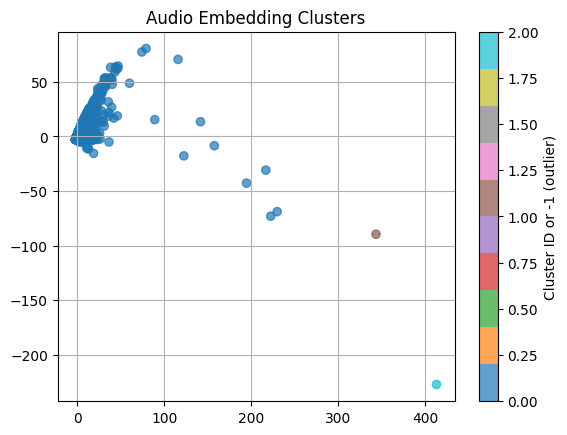

In [80]:
import matplotlib.pyplot as plt

plt.scatter(pca_data.get_samples()[:, 0], pca_data.get_samples()[:, 1], c=labels, cmap='tab10', alpha=0.7)
plt.title("Audio Embedding Clusters")
plt.colorbar(label='Cluster ID or -1 (outlier)')
plt.grid(True)
plt.show()